# Slide design: chunks, bullets or paragraphs?

Mike and Rieke  
2026-06-24

In [1]:
import os
import glob
import pandas as pd
import re
import random
import numpy as np
import scipy.stats as stats
import statsmodels.stats.multicomp as mc
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from plotnine import * 
from IPython.display import Markdown, display
from tabulate import tabulate

# Functions

In [2]:
# Function to read CSV and add condition column
def read_csv_with_condition(file_path):
    df = pd.read_csv(file_path, header=[0], skiprows = [1])
    condition_name = os.path.splitext(os.path.basename(file_path))[0].replace(study_name+"-", "")  # Get filename without extension and remove the study round
    df['condition'] = condition_name  # Add condition column
    df['conditionLength'] = int(condition_name.split('-')[0])
    df['conditionType'] = condition_name.split('-')[1]
    return df, condition_name

# Function to combine headers
def combine_headers(df):
    df.columns = [' '.join(col).strip() for col in df.columns.values]
    return df

# Clean remaining column names
def clean_column_names(columns):
    cleaned_columns = []
    for col in columns:
        col = re.sub(r'\bresponse\b', '', col, flags=re.IGNORECASE)
        col = re.sub(r'[^a-zA-Z0-9]', '_', col).lower()
        col = col.strip('_')
        cleaned_columns.append(col)
    return cleaned_columns
  
# Function to check answers and add correctness columns
def add_correctness_columns(df, answer_map):
    for column, correct_answer in answer_map.items():
        if column in df.columns:
            df[column] = df[column].fillna("")
            # Create a new column with 1 if correct, 0 if incorrect
            df[f'{column}_correct'] = np.where(df[column].str.strip().str.lower() == correct_answer.lower(), 1, 0)
    return df

# Function to add a total correct column for each participant
def add_total_correct_column(df):
    # Identify all correctness columns (columns ending with '_correct')
    correctness_columns = [col for col in df.columns if col.endswith('_correct')]
    # Sum the correctness columns to create the total correct column
    df['total_correct'] = df[correctness_columns].sum(axis=1)
    return df
  
# Function to merge the answers to a single question into one column
def merge_columnes(df, column_name, number_of_columns):
  #number_of_columns needs to be the total number, not just the ones that are to be merged
  loc_index = df.columns.get_loc(column_name)
  df[column_name] = df.iloc[:, loc_index:loc_index+number_of_columns].bfill(axis=1).iloc[:, 0]
  df.drop(df.columns[loc_index+1:loc_index+number_of_columns], axis=1, inplace=True)
  return df

#function to calculate and print U-test
def utest(cond1, cond2):
  results = {}

  for column in test_columns:
    df_combined_dropna = df_combined.dropna(subset = [column], inplace=False)
    U1, p = stats.mannwhitneyu(df_combined_dropna[column][df_combined_dropna['condition'] == cond1],
                df_combined_dropna[column][df_combined_dropna['condition'] == cond2], method="exact")
    results[column] = {'U1_stat': U1, 'p_value': p}
  
  df = pd.DataFrame.from_dict(results, orient = "index")
  df.index = test_column_names
  Markdown(tabulate(df, headers = ["U1 statistic", "p-value"]))

  display(Markdown(df.to_markdown()))

# Load data

In [3]:
study_name = "pg"
file_list = glob.glob(os.path.join(os.getcwd(), "data/2025-10-19_SurveyData", study_name+"*.csv"))

for f in file_list:
    print(os.path.basename(f))

df_combined = pd.DataFrame({})
condition_list = []

for i in range(len(file_list)):
  new_file, conditionname = read_csv_with_condition(file_list[i])
  df_combined = pd.concat([df_combined, new_file], ignore_index = True)
  condition_list.append(conditionname)

df_combined = df_combined.convert_dtypes()

pg-100-bullets.csv
pg-100-chunks.csv
pg-100-para.csv
pg-30-bullets.csv
pg-30-chunks.csv
pg-30-para.csv
pg-50-bullets.csv
pg-50-chunks.csv
pg-50-para.csv

# Clean data

Rename columns to make processing easier

In [4]:
rename_map = {
    'Please rate these slides I found the slides to be attractive.': 
      'slides_attractive',
    'In what year did the Tasmanian Tiger go extinct?': 
      'tiger_extinct_year',
    'What kind of animal would the Tasmanian Tiger be classified as?': 
      'tiger_classified',
    "What were the primary causes of the Tasmanian Tiger's extinction?": 
      'tiger_extinct_why',
    'Why are exoplanets important to the search for life beyond Earth?': 
      'why_exoplanets_important',
    'Why do scientists prioritize Earth-like planets in their search for life?': 
      'why_prioritize_earthlike_planets',
    'Exoplanets were discovered in which year?': 
      'exoplanets_discovered_year',
    'What do AI automation and chatbots primarily help reduce in customer service?': 
      'what_chatbots_reduce',
    'What role do CRM systems play in customer service?': 
      'what_role_crms_play',
    'What is the relationship between 24/7 support and overall efficiency in customer service?': 
      'relationship_24_7_efficiency',
    'Please rate these slides': 
      'slides_attractive',
    'Unnamed: 19': 
      'slides_clean_simple',
    'In reviewing the slides, I invested:': 
      'cognitive_load',
    'What is the highest level of education you have completed?  ': 
      'highest_education',
    'How often do you create presentations with slides (for yourself or others)?': 
      'creation_frequency',
    "Enter your email. This is just to make sure we only count you once. We won't spam you.": 'email'
}
df_combined.rename(columns=rename_map, inplace=True)

df_combined.columns = clean_column_names(df_combined.columns)

Remove empty columns

In [5]:
blank_columns = [col for col in df_combined.columns if df_combined[col].isna().all()]
df_combined.drop(columns=blank_columns, inplace=True)

Remove duplicates

In [6]:
#https://stackoverflow.com/questions/23512339/drop-duplicates-while-preserving-nans-in-pandas
df_combined = df_combined[(~df_combined.duplicated()) ]

# Evaluate correctness of answers

Dictionary with correct answers

In [7]:
correct_answers = {
    'tiger_extinct_year': '1936',
    'tiger_classified': 'Marsupial',
    'tiger_extinct_why': 'Hunting and habitat loss',
    'why_exoplanets_important': 
      'They may be habitable and contain liquid water, and biosignatures.',
    'why_prioritize_earthlike_planets': 
      'They might have liquid water and biosignatures.',
    'exoplanets_discovered_year': '1992',
    'what_chatbots_reduce': 'Wait times',
    'what_role_crms_play': 'They personalize experiences.',
    'relationship_24_7_efficiency': '24/7 support boosts efficiency.'
}

Check the answers and calculate total correct answers per participant

In [8]:
df_combined['tiger_extinct_year'] = df_combined['tiger_extinct_year'].astype(str)
df_combined['exoplanets_discovered_year'] = df_combined['exoplanets_discovered_year'].astype(str)

df_combined = add_correctness_columns(df_combined, correct_answers)
df_combined = add_total_correct_column(df_combined)

# Plots

> **Tip**
>
> These are bar graphs for each condition. The three columns correspond
> to the three text types, the three rows to the three text lengths. For
> how to read a bar graph, see for example
> [here](https://www.dummies.com/article/academics-the-arts/math/statistics/how-to-interpret-a-statistical-bar-graph-169760/).

## Total of correct answers

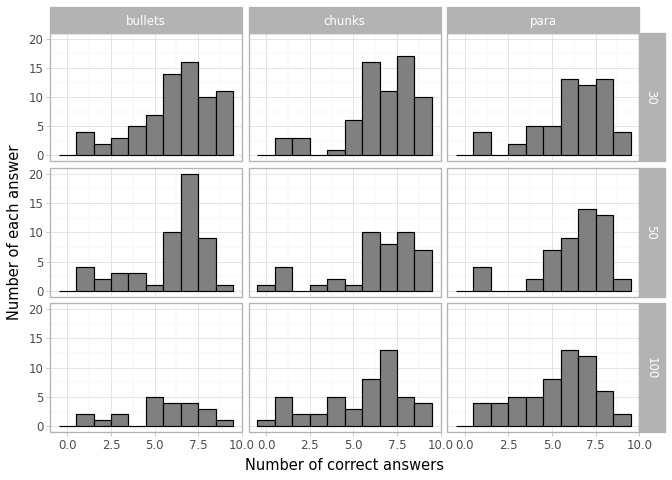

## Total slide attractiveness rating

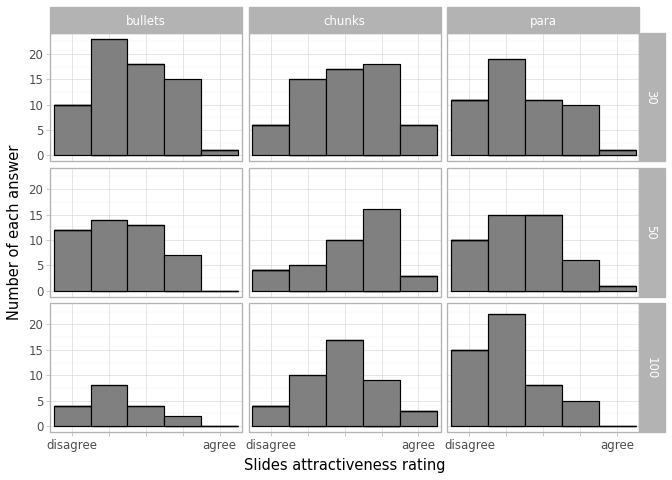

## Total slide cleanliness rating

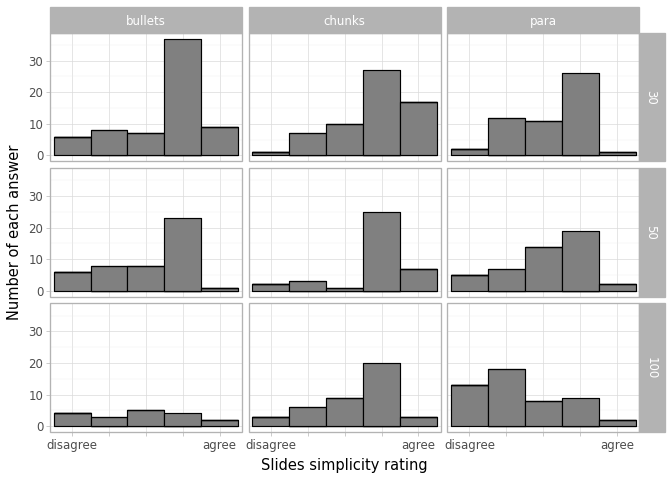

## Total cognitive load rating

> **Caution**
>
> Note that I swaped the x-axis to make it correspond to the previous
> plots (more right = better)

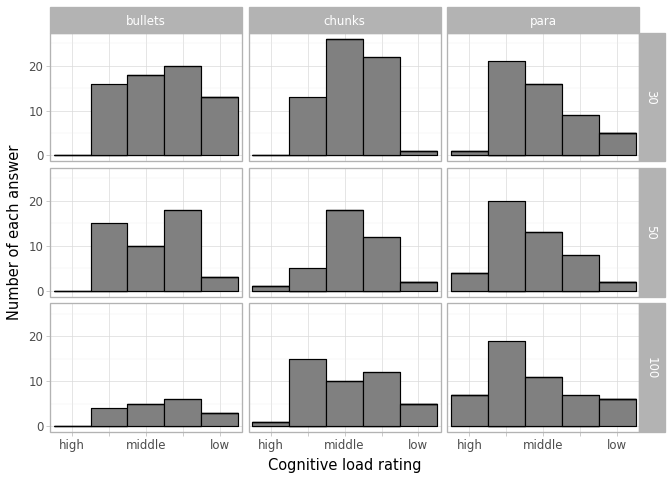

## How many for which question correct?

(not corrected for missing answers!)

In [13]:
only_correct_counts = df_combined.loc[:, df_combined.columns.str.endswith('correct') & ~df_combined.columns.str.startswith('total')]
print(only_correct_counts.sum()/len(only_correct_counts))

tiger_extinct_year_correct                  0.645570
tiger_classified_correct                    0.700422
tiger_extinct_why_correct                   0.704641
why_exoplanets_important_correct            0.765823
why_prioritize_earthlike_planets_correct    0.725738
exoplanets_discovered_year_correct          0.755274
what_chatbots_reduce_correct                0.685654
what_role_crms_play_correct                 0.436709
relationship_24_7_efficiency_correct        0.616034
dtype: float64

Order of questions 1. Tasmanian tiger 2. Exoplanets 3. AI chatbots

# Convert categorical data to numbers

For the statistical evaluation, the category based answers need to be
converted to numbers.

In [14]:
cognitive_load_scale = {
  "very high mental effort": 2,
  "high mental effort": 1,  
  "neither low nor high mental effort": 0, 
  "low mental effort": -1, 
  "very low mental effort": -2}

slides_scale = {"Strongly disagree": -2, "Disagree": -1, 
  "Neither agree nor disagree": 0, "Agree": 1, "Strongly agree": 2}
  
df_combined['cognitive_load_cat'] = df_combined['cognitive_load'].map(cognitive_load_scale)

df_combined['slides_attractive_cat'] = df_combined['slides_attractive'].map(slides_scale)
df_combined['slides_clean_simple_cat'] = df_combined['slides_clean_simple'].map(slides_scale)

# Statistics

In [15]:
test_columns = ['total_correct', 
  'cognitive_load_cat', 
  'slides_attractive_cat', 
  'slides_clean_simple_cat']
test_column_names = ['Correct answers', 
  'Cognitive Load', 
  'Slide Attractiveness', 
  'Slide Simplicity']

## sample sizes

Number of answers for each question and condition combination

## normal distribution

This is necessary to decide which test is adequate to test for a
difference between means.

> **Note**
>
> now Shapiro-Wilk-test (for sample size \<50), with larger sample size
> (\>40) use chi-squared test or maybe also Kolmogorov–Smirnov-test

> **Tip**
>
> non significant means normally distributed (or rather can’t reject the
> null hypothesis)

In [17]:
results = {}

for column in test_columns:
  new_dict = {}
  for condition in condition_list:
    df_combined_dropna = df_combined.dropna(subset = [column], inplace = False)
    S_result, p_value = stats.shapiro(df_combined_dropna[column][df_combined_dropna['condition'] == condition])
    new_dict[condition] = {'S_result': S_result, 'p_value': p_value}
  results[column] = new_dict

### Correct answers

|             | Shapiro result statistic |     p-value |
|:------------|-------------------------:|------------:|
| 100-bullets |                 0.928074 |    0.111871 |
| 100-chunks  |                 0.906391 |  0.00101774 |
| 100-para    |                 0.935612 |  0.00380742 |
| 30-bullets  |                 0.911671 | 9.28137e-05 |
| 30-chunks   |                 0.858825 | 1.98362e-06 |
| 30-para     |                 0.892523 | 9.24435e-05 |
| 50-bullets  |                  0.82047 | 1.55258e-06 |
| 50-chunks   |                 0.839768 |  2.4236e-05 |
| 50-para     |                 0.833444 | 4.75237e-06 |

### Cognitive Load

|             | Shapiro result statistic |     p-value |
|:------------|-------------------------:|------------:|
| 100-bullets |                 0.885074 |   0.0318019 |
| 100-chunks  |                 0.880614 | 0.000339894 |
| 100-para    |                 0.886674 | 0.000179516 |
| 30-bullets  |                 0.869574 | 4.47099e-06 |
| 30-chunks   |                 0.836777 | 9.16678e-07 |
| 30-para     |                 0.856992 | 1.73535e-05 |
| 50-bullets  |                 0.833451 | 1.17254e-05 |
| 50-chunks   |                 0.883091 | 0.000878357 |
| 50-para     |                 0.887397 | 0.000292304 |

### Slide Attractiveness

|             | Shapiro result statistic |     p-value |
|:------------|-------------------------:|------------:|
| 100-bullets |                 0.874863 |   0.0214176 |
| 100-chunks  |                 0.916034 |  0.00398035 |
| 100-para    |                 0.839971 | 8.37024e-06 |
| 30-bullets  |                 0.894702 | 3.48841e-05 |
| 30-chunks   |                 0.914255 | 0.000361399 |
| 30-para     |                  0.88698 | 0.000137857 |
| 50-bullets  |                 0.871061 | 0.000113873 |
| 50-chunks   |                 0.875408 | 0.000552997 |
| 50-para     |                 0.898979 | 0.000668267 |

### Slide Simplicity

|             | Shapiro result statistic |     p-value |
|:------------|-------------------------:|------------:|
| 100-bullets |                 0.910576 |   0.0880704 |
| 100-chunks  |                 0.853085 | 8.92888e-05 |
| 100-para    |                 0.874389 | 7.59361e-05 |
| 30-bullets  |                 0.804395 | 5.17545e-08 |
| 30-chunks   |                 0.855007 | 3.16259e-06 |
| 30-para     |                 0.816589 | 1.49115e-06 |
| 50-bullets  |                 0.809299 | 3.14212e-06 |
| 50-chunks   |                 0.708023 |  2.2238e-07 |
| 50-para     |                 0.869979 | 9.04645e-05 |

Result: most are not normally distributed (null hypothesis rejected
within alpha 0.05)

## Mann-Whitney U-test

they are not normally distributed, hence we use the U-test to test for
difference between means (variances and size of sample do not matter)

> **Tip**
>
> non significant means normally distributed (or rather can’t reject the
> null hypothesis)

> **Tip**
>
> You want to look for the cases, where the p value is below 0.05. This
> means there is a significant difference between the two conditions.

### Hypothesis 1: Chunks are most attractive

> **Important**
>
> (not really a best practice to use the same dataset to develop
> hypothesis and test it)

#### 30-chunks vs. 30-bullets

#### 30-chunks vs. 30-para

#### 50-chunks vs. 50-bullets

#### 50-chunks vs. 50-para

#### 100-chunks vs. 100-bullets

#### 100-chunks vs. 100-para

### Hypothesis 2: Bullets worse the longer

#### 30-bullets vs. 50-bullets

#### 30-bullets vs. 100-bullets

#### 50-bullets vs. 100-bullets

### Hypothesis 3: Long chunks don’t work

see Hypothesis 1

### other stuff

comparing the most extreme conditions

#### 30-chunks vs. 100-bullets

#### 30-bullets vs. 100-bullets

## Explorations

> **Tip**
>
> There are violin plots with an overlay box plot in this section. See
> for example
> [here](https://mode.com/blog/violin-plot-examples#how-to-read-violin-plot)
> for an explanation how to read it. In the other plots (beeswarm plots)
> each point corresponds to one answer. They are slightly offset in
> x-direction to make it easier to see.

### Correlation between cognitive load and correct answers?

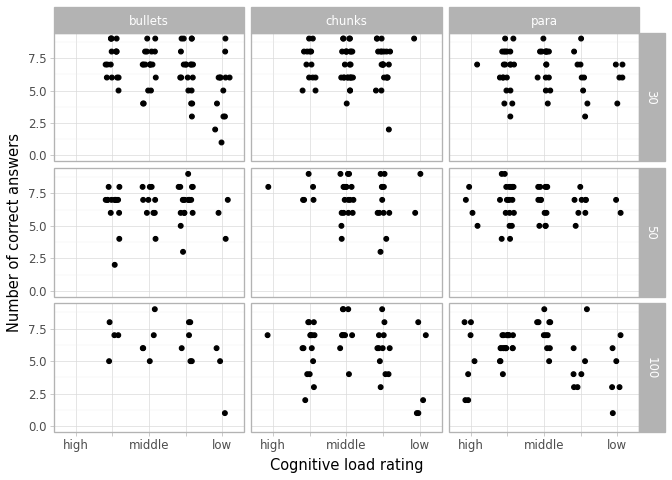

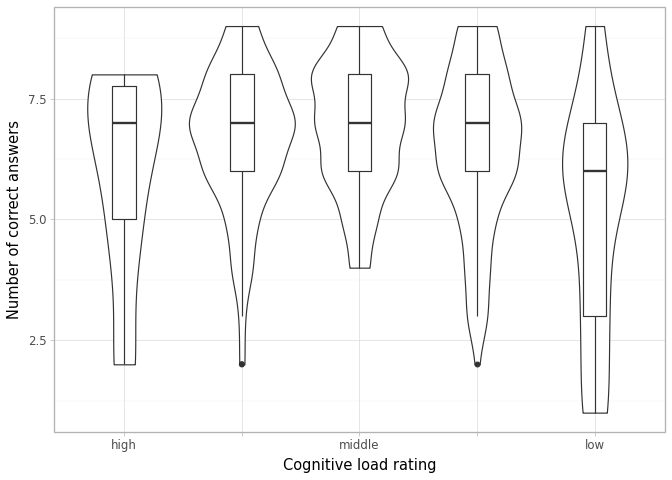

### Correlation between slide simplicity and correct answers?

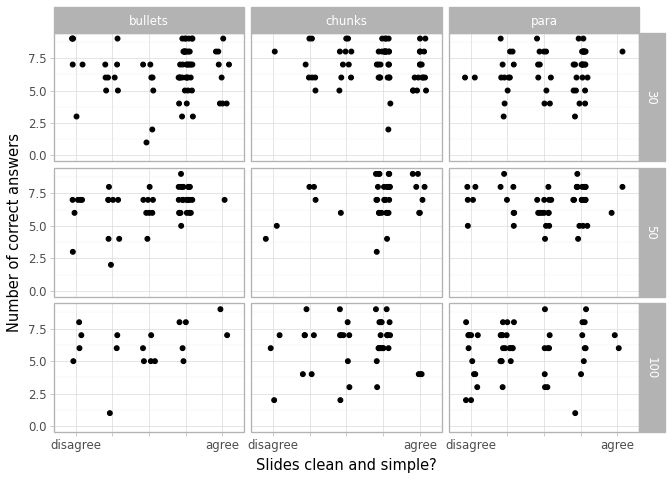

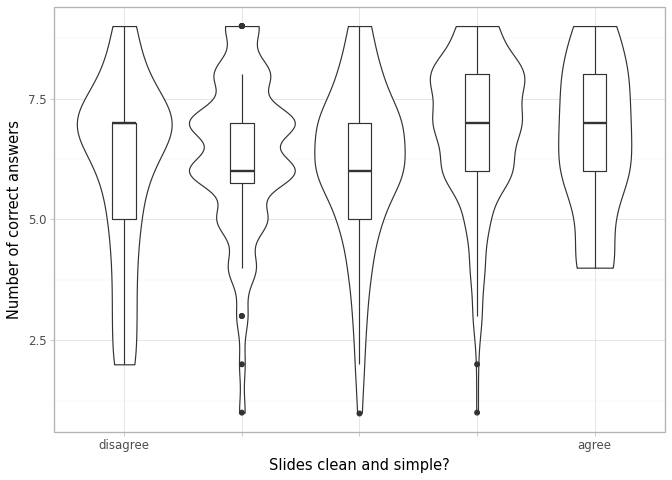

### Correlation between slide attractiveness and correct answers?

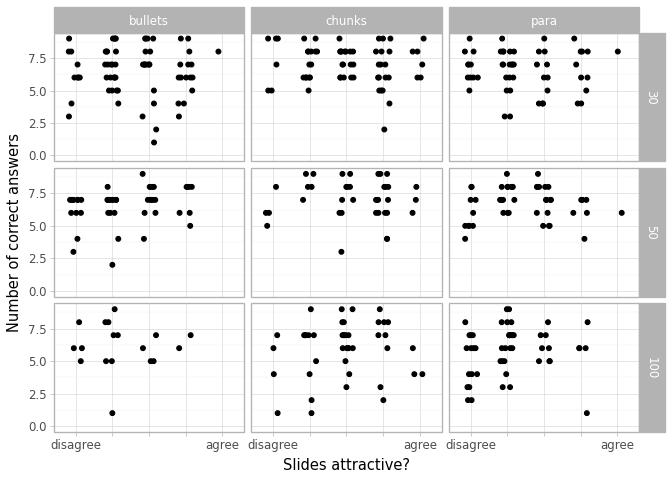

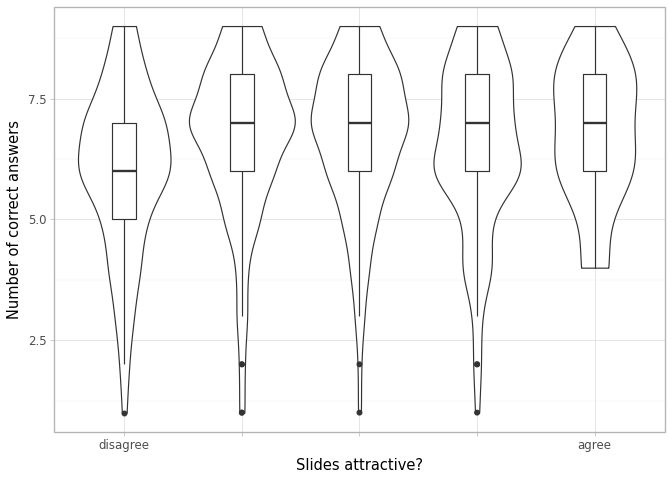

### Who stopped answering when?

Number of people starting in each condition

condition
100-bullets    22
100-chunks     48
100-para       59
30-bullets     72
30-chunks      67
30-para        58
50-bullets     53
50-chunks      44
50-para        51
dtype: Int64

Number of people who answered each question per condition

As the answer numbers per question theme is the same, I chose just one
question in each theme to count the answers.

There doesn’t seem to emerge a clear pattern (except maybe for the
paragraphs where in each condition the same number of people dropped out
after each question, but with that sample size that might just be
chance).

### Number of correct answers to first questions?

This is the number of correct answers for the first theme (total number,
not relative amount to the people that actually answered – check the
table above for an idea how many people answered).

In contrast, the number of correct answers for the following themes:

# Main Effects

The previous analysis used pairwise comparisons. Here, we test for the
main effects of slide length and format, as well as their interaction,
on our outcome variables.

This section moves from condition-by-condition comparisons to a
model-based view of the 3x3 design, so we can see whether length,
format, or their interaction explains the outcomes.

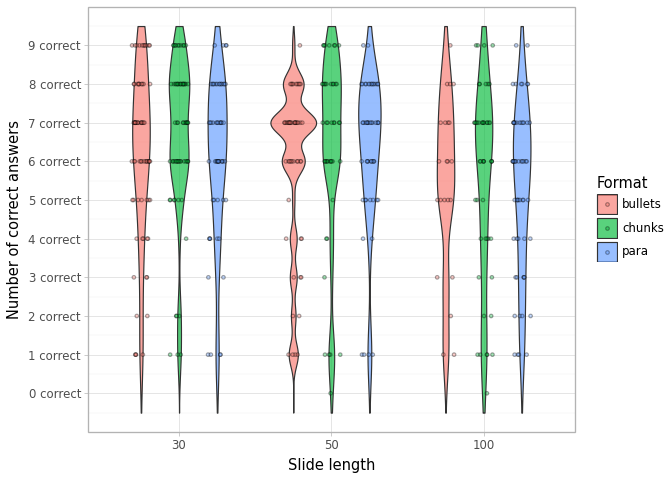

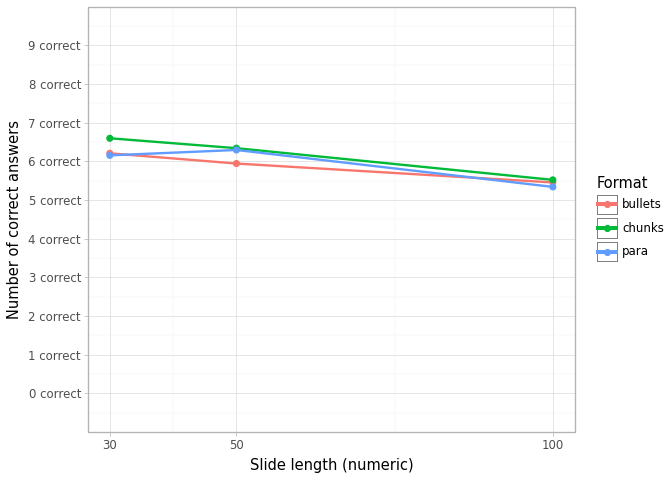

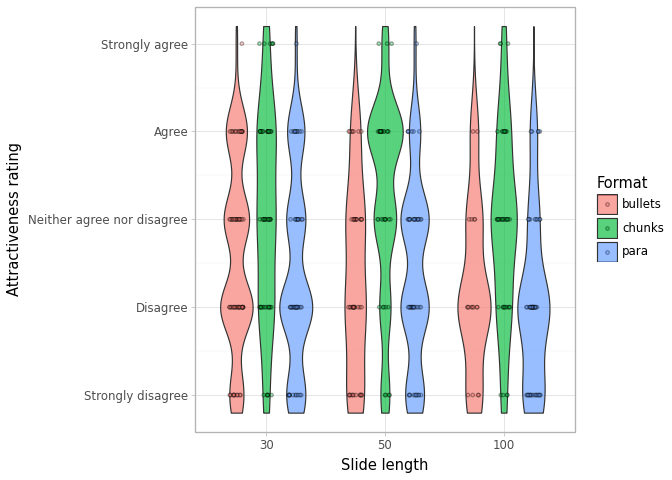

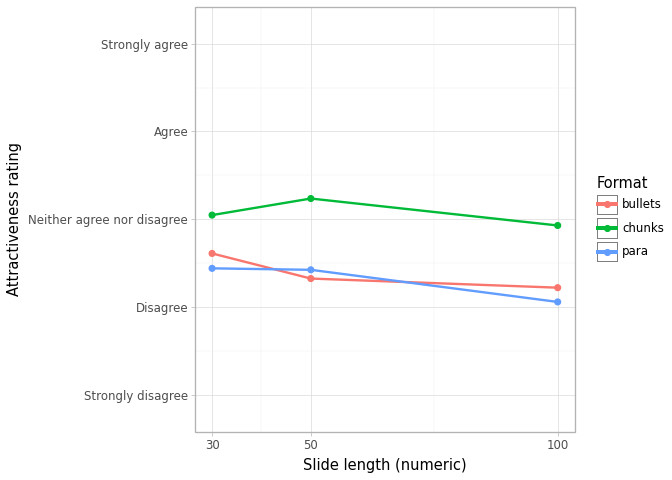

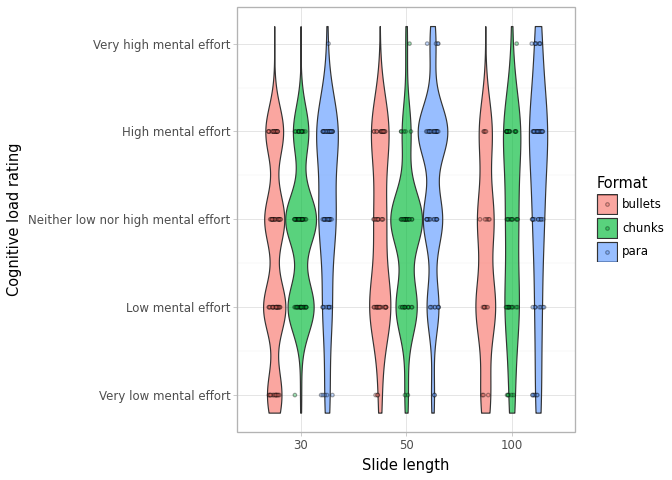

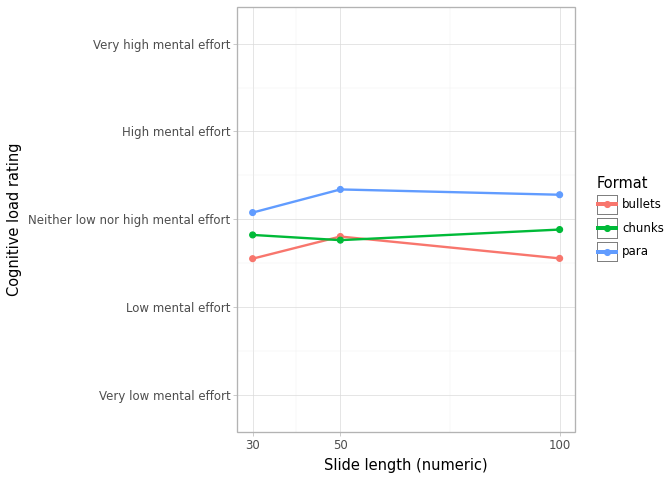

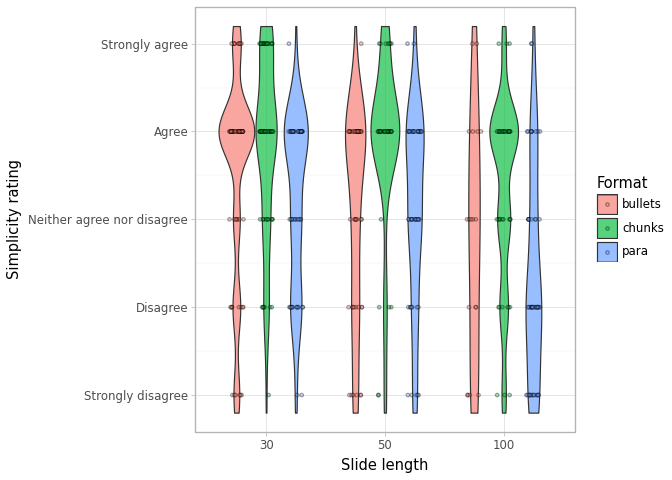

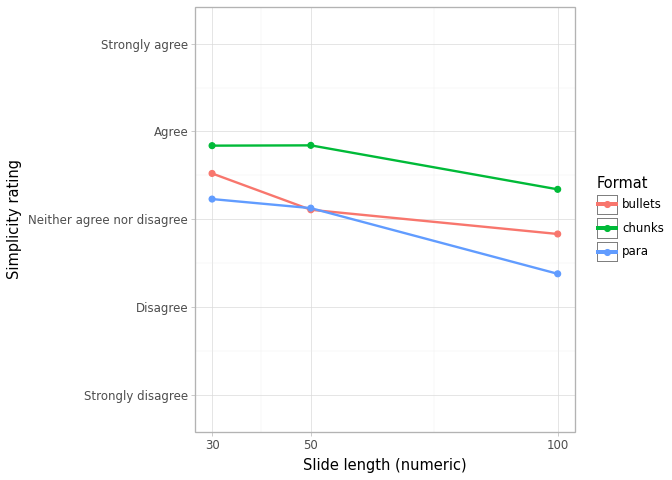